In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from pyod.models.ecod import ECOD
from pyod.models.cblof import CBLOF
from scipy.stats import spearmanr

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
CSV = "KPI Table(1).csv"
df = pd.read_csv(CSV, skip_blank_lines=True, low_memory=False)
df = df.dropna(how="all").reset_index(drop=True)

kpi_cols = list(df.columns[5:])          # les 9 colonnes KPI
print("Lignes x colonnes :", df.shape)
print("Regions:", df["Region"].nunique(),"| Nodes:", df["Node"].nunique(),"| Cellules:", df["EUtranCell Id"].nunique())
df.head()

Lignes x colonnes : (135917, 14)
Regions: 13 | Nodes: 503 | Cellules: 4654


,Region,Node,EUtranCell Id,Week,Date,EN_DC_SETUP_succ_RATE_gNB (%),EN_DC_SETUP_succ_RATE_eNB (%),EN_DC_intra_sgNB_PSCell_Change_succ_rate (%),EN_DC_inter_sgNB_PSCell_Change_succ_rate (%),SCG_Radio_Resource_Retainability_Act (%),SCG_Radio_Resource_Retainability_origin_gNb_Act (%),Diff_Init_E-Rab_Establish_Succ_Rate (%),Diff_E-RAB_Retainability (%),Diff_Cell_Mobility_Succ_Rate_LTE (%)
0,Gabes,NODE_0007,LGB910A,23,6/3/2026,99.17,99.95,100.00,94.80,1.10,0.21,99.99,0.24,99.25
1,Gabes,NODE_0007,LGB910A,23,6/4/2026,99.11,99.92,100.00,93.75,0.94,0.20,99.99,0.22,98.95
2,Gabes,NODE_0007,LGB910A,23,6/5/2026,98.82,99.87,99.96,97.56,1.14,0.21,100.00,0.12,99.04
3,Gabes,NODE_0007,LGB910A,23,6/6/2026,99.15,99.92,99.93,89.72,2.98,0.24,100.00,0.04,99.03
4,Gabes,NODE_0007,LGB910A,23,6/7/2026,99.08,99.97,100.00,85.26,3.71,0.22,100.00,0.07,99.57


In [3]:
df.dtypes

Region                                                  object
Node                                                    object
EUtranCell Id                                           object
Week                                                     int64
Date                                                    object
EN_DC_SETUP_succ_RATE_gNB (%)                           object
EN_DC_SETUP_succ_RATE_eNB (%)                           object
EN_DC_intra_sgNB_PSCell_Change_succ_rate (%)           float64
EN_DC_inter_sgNB_PSCell_Change_succ_rate (%)           float64
SCG_Radio_Resource_Retainability_Act (%)                object
SCG_Radio_Resource_Retainability_origin_gNb_Act (%)     object
Diff_Init_E-Rab_Establish_Succ_Rate (%)                 object
Diff_E-RAB_Retainability (%)                            object
Diff_Cell_Mobility_Succ_Rate_LTE (%)                    object
dtype: object

In [4]:
for c in kpi_cols:
    if df[c].dtype == object:
        bad = df[c][pd.to_numeric(df[c], errors="coerce").isna() & df[c].notna()]
        if len(bad):
            print(f"{c:50s} {list(bad.unique()[:3])}  ->  {len(bad)} lignes")

EN_DC_SETUP_succ_RATE_gNB (%)                      ['#DIV/0']  ->  738 lignes
EN_DC_SETUP_succ_RATE_eNB (%)                      ['#DIV/0']  ->  9632 lignes
SCG_Radio_Resource_Retainability_Act (%)           ['#DIV/0']  ->  738 lignes
SCG_Radio_Resource_Retainability_origin_gNb_Act (%) ['#DIV/0']  ->  738 lignes
Diff_Init_E-Rab_Establish_Succ_Rate (%)            ['#DIV/0']  ->  1719 lignes
Diff_E-RAB_Retainability (%)                       ['#DIV/0']  ->  10957 lignes
Diff_Cell_Mobility_Succ_Rate_LTE (%)               ['#DIV/0']  ->  10994 lignes


In [5]:
# Conversion en numerique. On garde les #DIV/0 en NaN  et on en garde la trace via un flag .
div0 = pd.DataFrame(False, index=df.index, columns=kpi_cols)
for c in kpi_cols:
    div0[c] = df[c].astype(str).str.contains("DIV", na=False)
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["had_div0_any_kpi"] = div0.any(axis=1)
print("Lignes avec au moins un #DIV/0 :", int(df["had_div0_any_kpi"].sum()))

Lignes avec au moins un #DIV/0 : 11581


In [ ]:
# --- Preprocessing des NaN (ex-#DIV/0) ---
df["n_nan_kpi"] = df[kpi_cols].isna().sum(axis=1)
print("KPI manquants par ligne :")
print(df["n_nan_kpi"].value_counts().sort_index())

n_all_nan = int((df["n_nan_kpi"] == len(kpi_cols)).sum())
mask_drop = df["n_nan_kpi"] >= 6
print(f"\nLignes 100% NaN (aucun KPI ce jour-la) : {n_all_nan}")
print(f"Lignes retirees (>=6 KPI manquants)    : {int(mask_drop.sum())}")

n_before = len(df)
df = df[~mask_drop].reset_index(drop=True)
print(f"Lignes : {n_before} -> {len(df)}")

KPI manquants par ligne :
n_nan_kpi
0    124327
1      1005
2       870
3      7594
4      1389
6       390
7       276
8        13
9        53
Name: count, dtype: int64

Lignes 100% NaN (aucun KPI ce jour-la) : 53
Lignes retirees (>=6 KPI manquants)    : 732
Lignes : 135917 -> 135185


In [7]:
# Dates, jour de la semaine, week-end, et controle des doublons
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df["day_of_week"] = df["Date"].dt.day_name()
df["is_weekend"] = df["Date"].dt.dayofweek >= 5
print("Periode :", df["Date"].min().date(), "->", df["Date"].max().date())
print("Doublons (cellule, date) :", int(df.duplicated(["EUtranCell Id", "Date"]).sum()))

Periode : 2026-06-03 -> 2026-07-02
Doublons (cellule, date) : 0


In [8]:
missing = pd.DataFrame({
    "n_missing": df[kpi_cols].isna().sum(),
    "pct": (df[kpi_cols].isna().mean() * 100).round(2),
})
missing.sort_values("pct", ascending=False)

,n_missing,pct
Diff_Cell_Mobility_Succ_Rate_LTE (%),10292,7.61
Diff_E-RAB_Retainability (%),10255,7.59
EN_DC_SETUP_succ_RATE_eNB (%),8909,6.59
Diff_Init_E-Rab_Establish_Succ_Rate (%),1411,1.04
EN_DC_SETUP_succ_RATE_gNB (%),72,0.05
SCG_Radio_Resource_Retainability_Act (%),72,0.05
SCG_Radio_Resource_Retainability_origin_gNb_Act (%),72,0.05
EN_DC_inter_sgNB_PSCell_Change_succ_rate (%),0,0.00
EN_DC_intra_sgNB_PSCell_Change_succ_rate (%),0,0.00


In [9]:
# Completude par cellule :cellule apparaissant un nombre faible de jours -> moyennes moins fiables.
cell_days = df.groupby("EUtranCell Id").size()
print("Cellules totales   :", len(cell_days))
print("Avec 30 jours      :", int((cell_days == 30).sum()))
print("Moins de 25 jours  :", int((cell_days < 25).sum()))
print("Moins de 20 jours  :", int((cell_days < 20).sum()))

Cellules totales   : 4645
Avec 30 jours      : 4325
Moins de 25 jours  : 215
Moins de 20 jours  : 179


In [10]:
# Statistiques descriptives des 9 KPI
df[kpi_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

,mean,std,min,25%,50%,75%,max
EN_DC_SETUP_succ_RATE_gNB (%),98.91,1.82,79.89,99.05,99.46,99.67,100.00
EN_DC_SETUP_succ_RATE_eNB (%),97.98,7.45,0.00,99.12,99.61,99.83,100.00
EN_DC_intra_sgNB_PSCell_Change_succ_rate (%),99.96,0.06,98.06,99.94,99.97,100.00,100.00
EN_DC_inter_sgNB_PSCell_Change_succ_rate (%),94.67,14.84,0.00,97.76,99.98,100.00,100.00
SCG_Radio_Resource_Retainability_Act (%),1.20,1.57,0.00,0.37,0.61,1.33,20.69
SCG_Radio_Resource_Retainability_origin_gNb_Act (%),0.27,0.54,0.00,0.10,0.15,0.26,20.42
Diff_Init_E-Rab_Establish_Succ_Rate (%),99.95,0.30,57.92,99.97,99.99,100.00,100.00
Diff_E-RAB_Retainability (%),0.35,2.00,0.00,0.03,0.08,0.16,100.00
Diff_Cell_Mobility_Succ_Rate_LTE (%),98.51,4.06,0.00,98.59,99.32,99.71,100.00


In [11]:
# Controle de coherence : les KPI en % doivent rester dans [0, 100]
n_oob = 0
for c in kpi_cols:
    oob = int(((df[c] < 0) | (df[c] > 100)).sum())
    n_oob += oob
    if oob:
        print(c, "->", oob, "valeurs hors [0,100]")
print("Total valeurs hors bornes :", n_oob)

Total valeurs hors bornes : 0


EN_DC_SETUP_succ_RATE_gNB (%)                          -4.49
EN_DC_SETUP_succ_RATE_eNB (%)                          -6.79
EN_DC_intra_sgNB_PSCell_Change_succ_rate (%)           -5.93
EN_DC_inter_sgNB_PSCell_Change_succ_rate (%)           -4.16
SCG_Radio_Resource_Retainability_Act (%)                3.56
SCG_Radio_Resource_Retainability_origin_gNb_Act (%)    13.56
Diff_Init_E-Rab_Establish_Succ_Rate (%)               -48.68
Diff_E-RAB_Retainability (%)                           16.73
Diff_Cell_Mobility_Succ_Rate_LTE (%)                  -12.26
dtype: float64


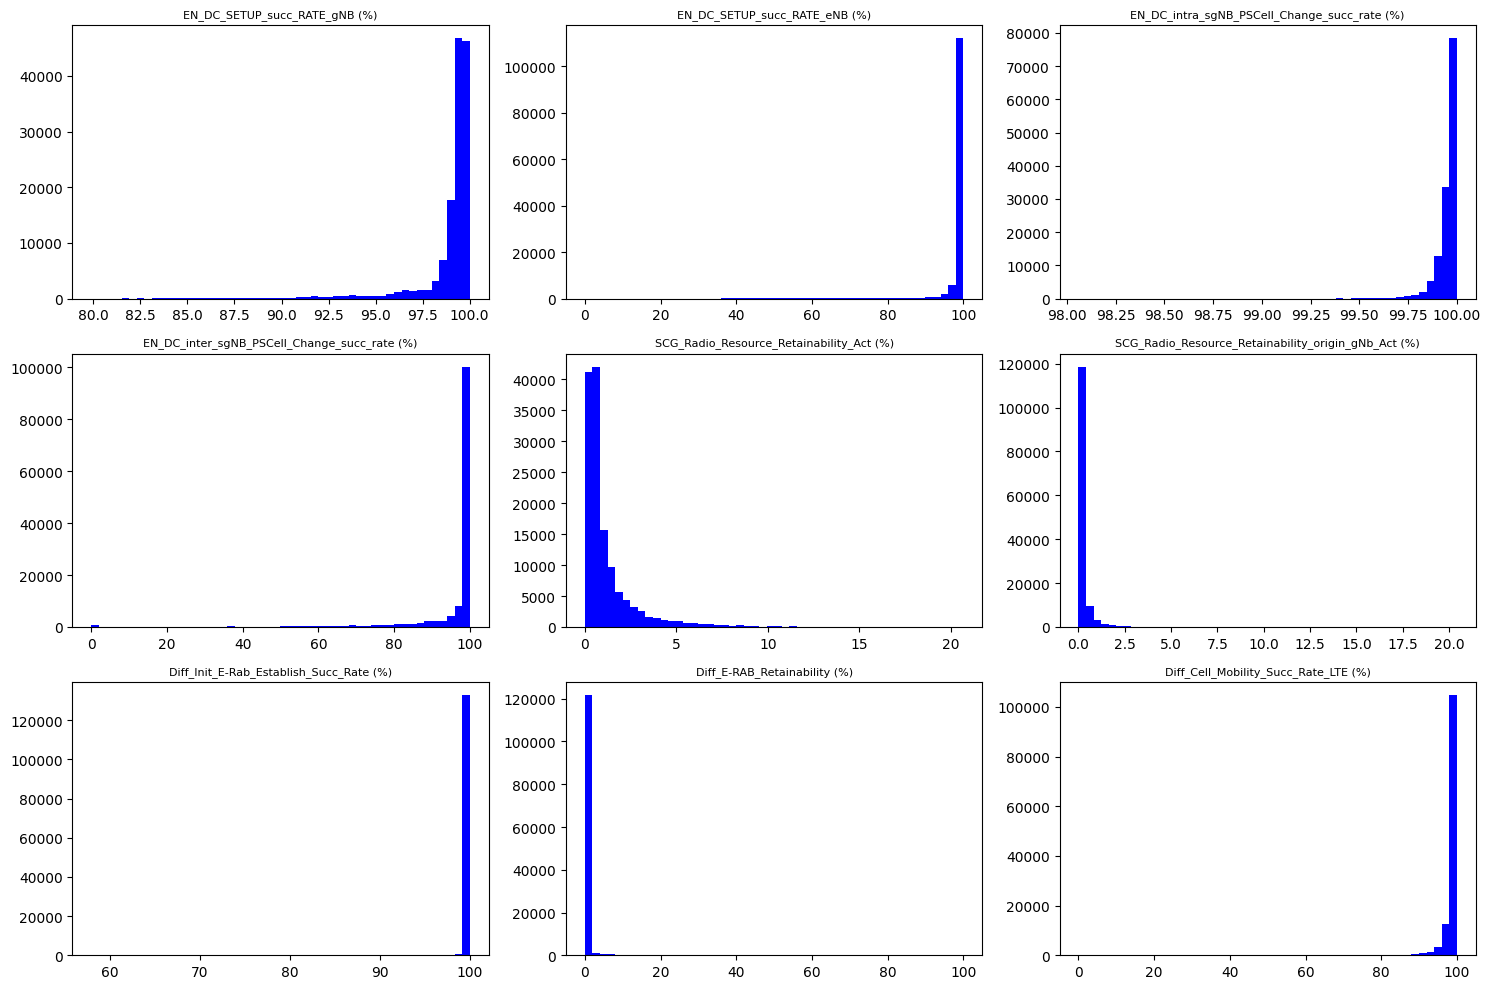

In [12]:
print(df[kpi_cols].skew().round(2))
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, c in zip(axes.ravel(), kpi_cols):
    ax.hist(df[c].dropna(), bins=50, color="blue")
    ax.set_title(c, fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Distribution des 9 KPI (skew + histogrammes) tres asymetriques
# taux de succes ecrases vers 100, taux de perte vers 0. Une regle 1.5xIQR ou un
# z-score classique (moyenne/ecart-type) est peu fiable -> on ira vers du robuste.

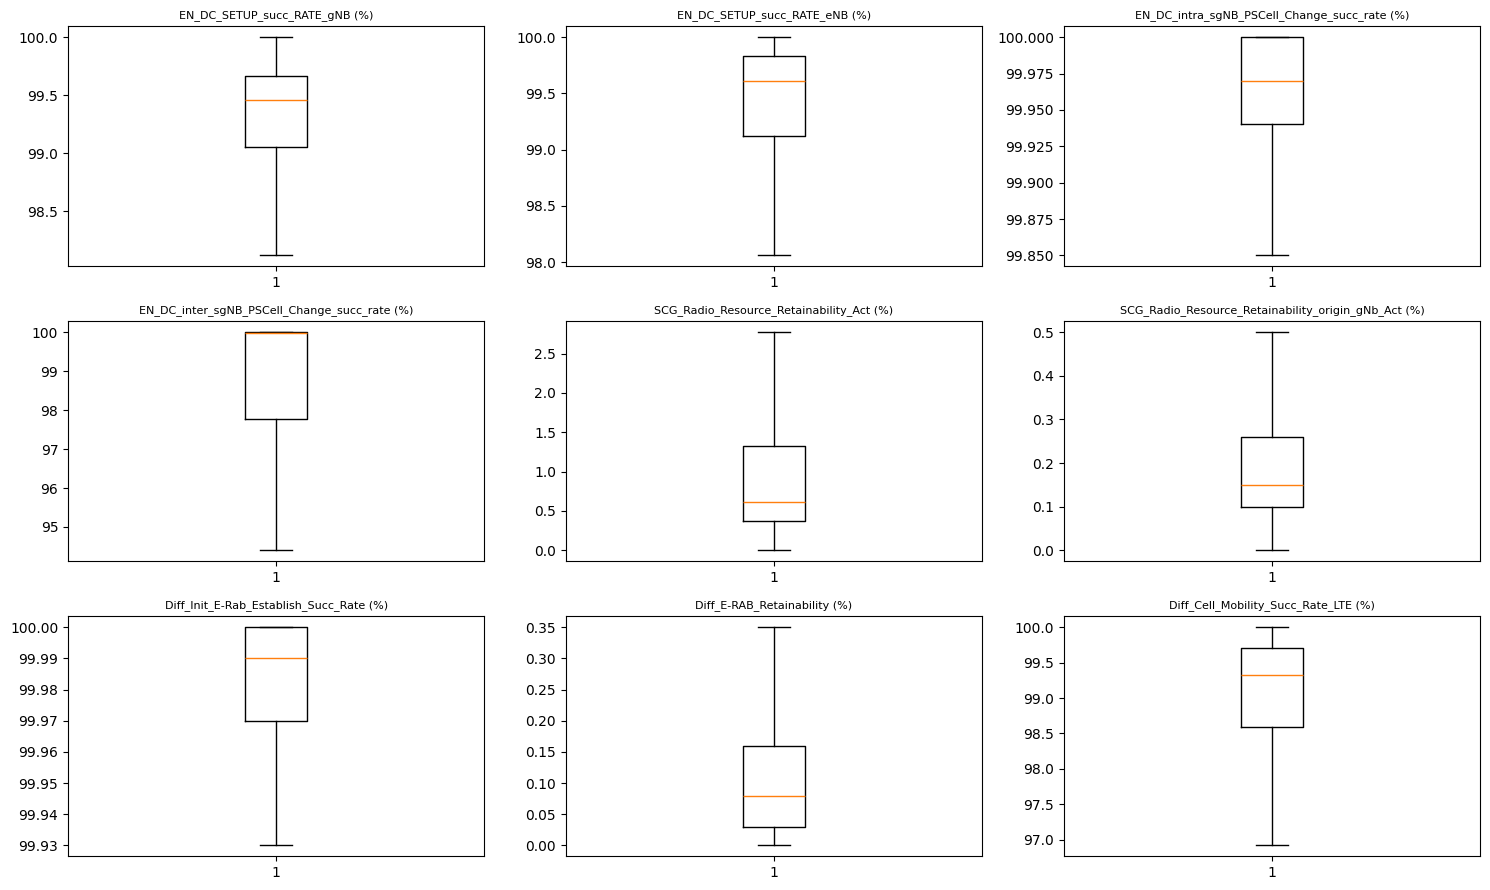

In [14]:
# Boxplots des 9 KPI
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, c in zip(axes.ravel(), kpi_cols):
    ax.boxplot(df[c].dropna(), showfliers=False)
    ax.set_title(c, fontsize=8)
plt.tight_layout()
plt.show()

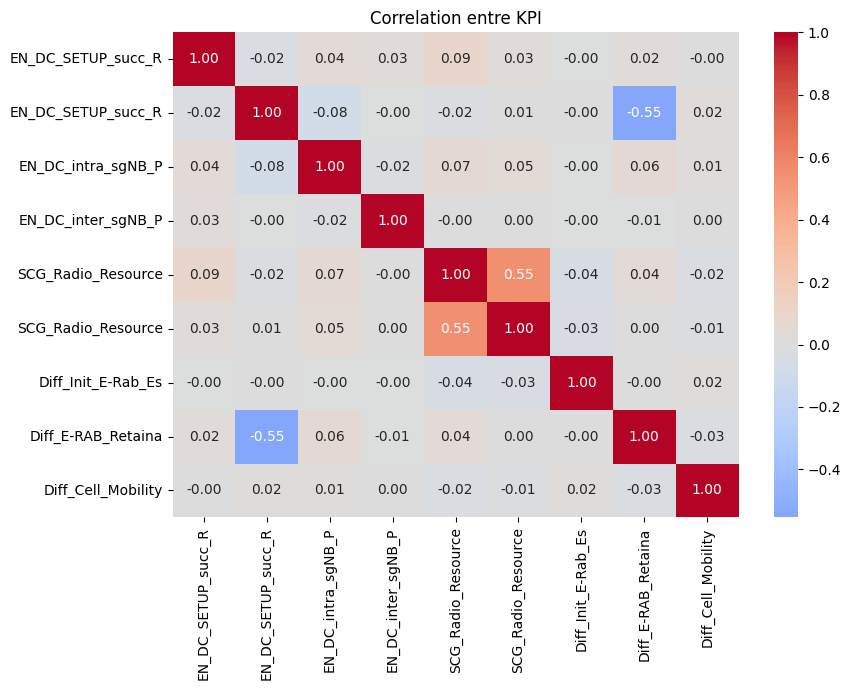

In [15]:
corr = df[kpi_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=[c[:18] for c in kpi_cols],
            yticklabels=[c[:18] for c in kpi_cols])
plt.title("Correlation entre KPI")
plt.tight_layout()
plt.show()

In [16]:
# Correlation entre KPI : globalement faible. Deux paires ressortent (~0.55) mais
# pas assez pour retirer un KPI -> on garde les 9 comme features.

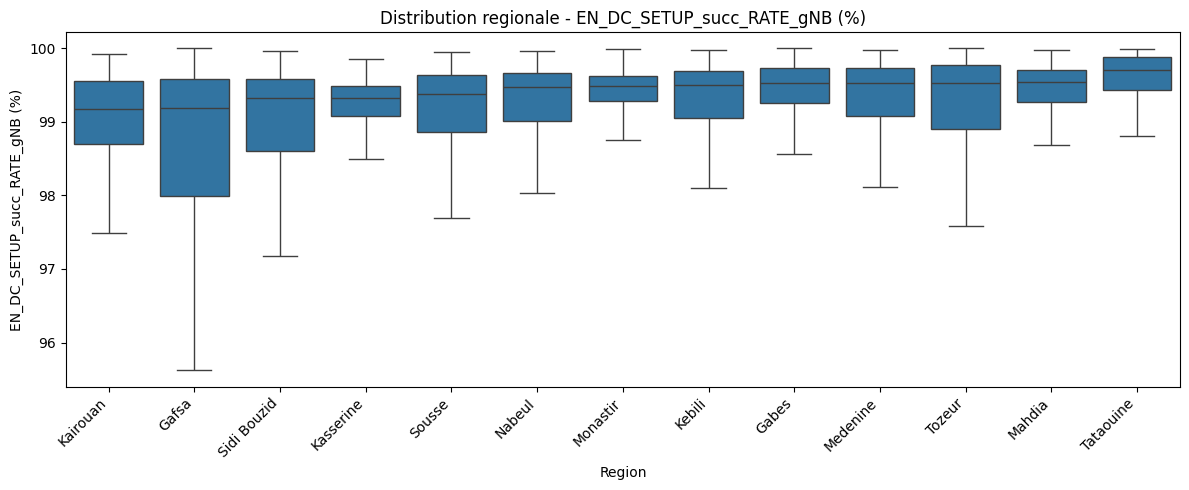

In [17]:
test_kpi = "EN_DC_SETUP_succ_RATE_gNB (%)"
order = df.groupby("Region")[test_kpi].median().sort_values().index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="Region", y=test_kpi, order=order, showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.title(f"Distribution regionale - {test_kpi}")
plt.tight_layout()
plt.show()

In [18]:
# Comparaison par region : les medianes sont quasi identiques (~99%) -> les regions sont homogenes, aucune n'est structurellement avantagee.
# Le choix "baseline par region et non par cellule" vient de l'objectif :  on veut detecter les cellules chroniquement sous leurs pairs. Une baseline par
# cellule (chaque cellule comparee a son propre historique) donnerait z~0 pour une cellule toujours basse -> invisible. La cellule reste l'unite analysee, mais la
# reference est les pairs regionaux, pas son propre historique.

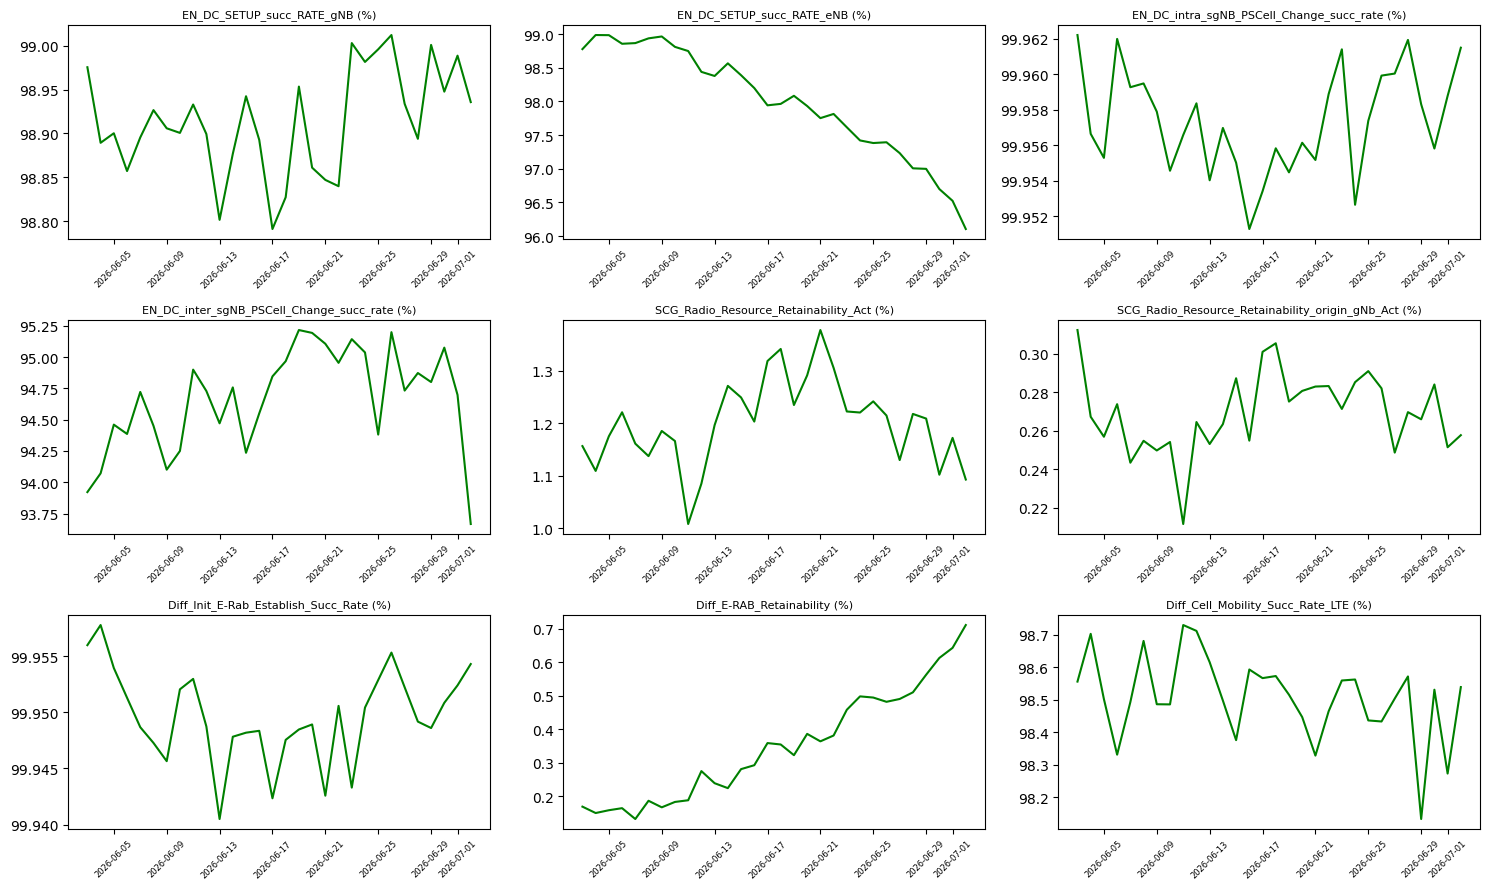

In [19]:
# Tendance temporelle du reseau : controle de stabilite pour valider la baseline statique.
daily = df.groupby("Date")[kpi_cols].mean()
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, c in zip(axes.ravel(), kpi_cols):
    ax.plot(daily.index, daily[c], color="green")
    ax.set_title(c, fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=6)
plt.tight_layout()
plt.show()

In [ ]:
# La plupart des KPI oscillent sans tendance (bruit normal). Exception : EN_DC_SETUP_succ_RATE_eNB et Diff_E-RAB_Retainibility derivent
# de ~99% a ~96% et de 0.15% a 0.7% sur le mois -> derive globale du reseau (toutes cellules a la fois), pas une anomalie de cellule,

In [21]:
# Effet jour de semaine (week-end vs semaine)
# concentration des #DIV/0 par region, a titre de controle.
print(df.groupby("is_weekend")[kpi_cols].mean().round(2).T)
print()
print("Part de lignes #DIV/0 par region (%) :")
print((df.groupby("Region")["had_div0_any_kpi"].mean() * 100).round(2).sort_values(ascending=False))

is_weekend                                          False  True 
EN_DC_SETUP_succ_RATE_gNB (%)                       98.93  98.87
EN_DC_SETUP_succ_RATE_eNB (%)                       97.95  98.07
EN_DC_intra_sgNB_PSCell_Change_succ_rate (%)        99.96  99.96
EN_DC_inter_sgNB_PSCell_Change_succ_rate (%)        94.62  94.78
SCG_Radio_Resource_Retainability_Act (%)             1.19   1.23
SCG_Radio_Resource_Retainability_origin_gNb_Act...   0.27   0.26
Diff_Init_E-Rab_Establish_Succ_Rate (%)             99.95  99.95
Diff_E-RAB_Retainability (%)                         0.36   0.31
Diff_Cell_Mobility_Succ_Rate_LTE (%)                98.52  98.47

Part de lignes #DIV/0 par region (%) :
Region
Tozeur         15.61
Gafsa          15.13
Kebili         12.93
Sidi Bouzid    12.17
Tataouine      10.93
Nabeul         10.92
Medenine        7.95
Kairouan        6.91
Gabes           6.15
Kasserine       5.26
Monastir        4.92
Sousse          4.54
Mahdia          3.95
Name: had_div0_any_kpi, dtype:

In [22]:
# --- Feature engineering : z-score robuste regional au niveau CELLULE-JOUR ---
# Approche journaliere : detecter les JOURS ou une cellule s'ecarte de ses pairs regionaux
# (pour correler ensuite aux reclamations). Pas d'agregation mensuelle.
# La baseline (mediane + MAD par region) est calculee UNIQUEMENT sur les cellules a
# historique fiable (>=20 jours) ; l'ecart est ensuite mesure pour TOUTES les cellules-jours.
reliable = cell_days[cell_days >= 20].index
ref = df[df["EUtranCell Id"].isin(reliable)]

z = pd.DataFrame(index=df.index)
for c in kpi_cols:
    med = df["Region"].map(ref.groupby("Region")[c].median())
    mad = df["Region"].map(ref.groupby("Region")[c].apply(lambda s: (s - s.median()).abs().median()))
    scale = (1.4826 * mad).replace(0, np.nan)      # MAD nulle -> dispersion nulle, z indefini
    z["z_" + c] = (df[c] - med) / scale
z = z.clip(-10, 10)
z_cols = list(z.columns)
df = pd.concat([df, z], axis=1)
print("Cellules fiables pour la baseline (>=20 j) :", len(reliable), "/", len(cell_days))
z[z_cols].describe().T[["mean", "std", "min", "max"]].round(2)

Cellules fiables pour la baseline (>=20 j) : 4466 / 4645


,mean,std,min,max
z_EN_DC_SETUP_succ_RATE_gNB (%),-0.90,2.64,-10.00,2.11
z_EN_DC_SETUP_succ_RATE_eNB (%),-1.12,2.87,-10.00,1.12
z_EN_DC_intra_sgNB_PSCell_Change_succ_rate (%),-0.37,1.48,-10.00,0.90
z_EN_DC_inter_sgNB_PSCell_Change_succ_rate (%),-2.56,4.25,-10.00,0.67
z_SCG_Radio_Resource_Retainability_Act (%),1.07,2.66,-1.55,10.00
z_SCG_Radio_Resource_Retainability_origin_gNb_Act (%),0.74,2.31,-1.73,10.00
z_Diff_Init_E-Rab_Establish_Succ_Rate (%),-1.30,2.85,-10.00,0.67
z_Diff_E-RAB_Retainability (%),0.78,2.41,-1.08,10.00
z_Diff_Cell_Mobility_Succ_Rate_LTE (%),-0.72,2.21,-10.00,1.09


In [ ]:
# Cellules a faible historique (<20 jours) : ecartees de la baseline (peu fiables) mais
# leurs jours restent scores. Gardees a part, jamais etiquetees "chronique".
cell_low = cell_days[cell_days < 20]
print("Cellules a faible historique (<20 j) :", len(cell_low))

Cellules a faible historique (<20 j) : 179
Cellules-jours a scorer : (135185, 9)


In [ ]:
# --- Modeles non supervises au niveau cellule-jour ---
CONTAMINATION = 0.03
X_scaled = StandardScaler().fit_transform(X)

iforest = IsolationForest(n_estimators=150, contamination=CONTAMINATION, random_state=RANDOM_STATE)
iforest.fit(X_scaled)
score_if = -iforest.score_samples(X_scaled)

pca = PCA(n_components=0.8, random_state=RANDOM_STATE)
pca.fit(X_scaled)
recon = pca.inverse_transform(pca.transform(X_scaled))
score_pca = ((X_scaled - recon) ** 2).sum(axis=1)

score_ecod = ECOD(contamination=CONTAMINATION).fit(X_scaled).decision_scores_
score_cblof = CBLOF(contamination=CONTAMINATION, n_clusters=8, random_state=RANDOM_STATE).fit(X_scaled).decision_scores_

scores_all = {"IForest": score_if, "PCA": score_pca, "ECOD": score_ecod, "CBLOF": score_cblof}
flags = {n: s >= np.quantile(s, 1 - CONTAMINATION) for n, s in scores_all.items()}
D["score_if"] = score_if
D["score_pca"] = score_pca
D["score_ecod"] = score_ecod
D["score_cblof"] = score_cblof
flag_if = flags["IForest"]
D["flag"] = flag_if                                         # flag journalier de reference = Isolation Forest
D["n_models"] = np.sum(list(flags.values()), axis=0)        # nb de modeles qui flaguent la cellule-jour
for n in flags:
    print(f"{n:9s} flagues : {int(flags[n].sum())}")
print("Cellules-jours flaguees par les 4 modeles :", int((D["n_models"] == 4).sum()))

IForest   flagues : 4056
PCA       flagues : 4056
ECOD      flagues : 4056
CBLOF     flagues : 4056
Cellules-jours flaguees par les 4 modeles : 98


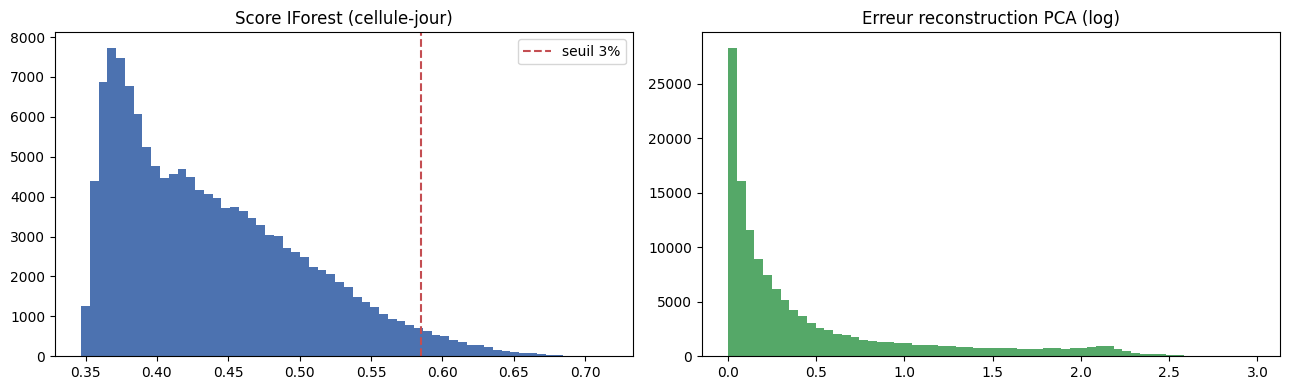

,EUtranCell Id,Date,Region,score_if,score_pca
103066,LSO275X,2026-06-26,Sousse,0.715139,0.121900
92506,LHM031X,2026-06-14,Nabeul,0.712367,11.615063
103065,LSO275X,2026-06-25,Sousse,0.709485,0.078953
64509,LMO311Q,2026-06-10,Monastir,0.708135,0.281037
92472,LHM031Q,2026-06-10,Nabeul,0.705926,14.962756
92475,LHM031Q,2026-06-13,Nabeul,0.704329,14.429565
103055,LSO275X,2026-06-15,Sousse,0.703991,2.152600
93263,LNA187P,2026-06-21,Nabeul,0.703303,2.247238
102793,LSO275A,2026-06-23,Sousse,0.703025,0.793625
92502,LHM031X,2026-06-10,Nabeul,0.702968,5.838506


In [26]:
# Distribution des scores + top cellules-jours les plus anormales (IForest).
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(score_if, bins=60, color="#4C72B0")
ax[0].axvline(np.quantile(score_if, 1 - CONTAMINATION), color="#C44E52", ls="--", label="seuil 3%")
ax[0].set_title("Score IForest (cellule-jour)"); ax[0].legend()
ax[1].hist(np.log1p(score_pca), bins=60, color="#55A868")
ax[1].set_title("Erreur reconstruction PCA (log)")
plt.tight_layout(); plt.show()

D.sort_values("score_if", ascending=False).head(10)[["EUtranCell Id", "Date", "Region", "score_if", "score_pca"]]

In [27]:
# Accord de rang entre les quatre modeles (Spearman).
rank_corr = pd.DataFrame(
    {"IForest": score_if, "PCA": score_pca, "ECOD": score_ecod, "CBLOF": score_cblof}
).corr(method="spearman")
rank_corr.round(2)

,IForest,PCA,ECOD,CBLOF
IForest,1.00,0.57,0.65,0.84
PCA,0.57,1.00,0.30,0.55
ECOD,0.65,0.30,1.00,0.59
CBLOF,0.84,0.55,0.59,1.00


In [28]:
# --- Validation 1 : stabilite par bootstrap ---
# Trop de lignes pour re-entrainer sur tout le jeu -> on evalue la stabilite sur un
# echantillon de cellules-jours, en re-entrainant sur des tirages bootstrap. On mesure la
# stabilite du top-k (Jaccard) et de l'ordre des scores (Spearman).
def jaccard(a, b):
    return len(a & b) / len(a | b)

rng = np.random.RandomState(RANDOM_STATE)
sub = rng.choice(len(X_scaled), 25000, replace=False)
Xs = X_scaled[sub]
k = int(CONTAMINATION * len(Xs))
n_runs = 8
tops = {"IForest": [], "PCA": [], "ECOD": [], "CBLOF": []}
ranks = {"IForest": [], "PCA": [], "ECOD": [], "CBLOF": []}
for b in range(n_runs):
    idx = rng.choice(len(Xs), len(Xs), replace=True)
    Xb = Xs[idx]
    s_if = -IsolationForest(n_estimators=100, contamination=CONTAMINATION, random_state=b).fit(Xb).score_samples(Xs)
    pb = PCA(n_components=0.8, random_state=b).fit(Xb)
    s_pca = ((Xs - pb.inverse_transform(pb.transform(Xs))) ** 2).sum(axis=1)
    s_ecod = ECOD(contamination=CONTAMINATION).fit(Xb).decision_function(Xs)
    s_cblof = CBLOF(contamination=CONTAMINATION, n_clusters=8, random_state=b).fit(Xb).decision_function(Xs)
    for name, s in [("IForest", s_if), ("PCA", s_pca), ("ECOD", s_ecod), ("CBLOF", s_cblof)]:
        tops[name].append(set(np.argsort(s)[::-1][:k]))
        ranks[name].append(s)
for name in tops:
    js = [jaccard(tops[name][i], tops[name][j]) for i in range(n_runs) for j in range(i + 1, n_runs)]
    sp = [spearmanr(ranks[name][i], ranks[name][j]).correlation for i in range(n_runs) for j in range(i + 1, n_runs)]
    print(f"{name:9s} Jaccard top-{k} = {np.mean(js):.3f}   Spearman = {np.mean(sp):.3f}")

IForest   Jaccard top-750 = 0.688   Spearman = 0.981
PCA       Jaccard top-750 = 0.906   Spearman = 0.995
ECOD      Jaccard top-750 = 0.974   Spearman = 1.000
CBLOF     Jaccard top-750 = 0.456   Spearman = 0.922


In [29]:
# --- Validation 2 : injection d'anomalies synthetiques ---
# On part de cellules-jours "propres" (non flaguees par |z|>3) et on injecte une degradation
# connue mais SUBTILE : 1 ou 2 KPI seulement, baisse uniform(3, 5) (pres de la frontiere
# |z|>3). Amplitude/nb de KPI reduits volontairement pour un test discriminant (sinon tous
# les modeles plafonnent). Metriques SANS SEUIL : ROC-AUC et average precision (aire sous la
# courbe precision-rappel), calculees sur tout le classement -> plus fines qu'un P/R a un seuil.
from sklearn.metrics import roc_auc_score, average_precision_score
clean_idx = np.where(~naive_flag)[0]
sub = rng.choice(clean_idx, 30000, replace=False)
Xc = X[sub].copy()
n_inject = 300
inj = rng.choice(len(Xc), n_inject, replace=False)
for i in inj:
    m = rng.randint(1, 3)                          # 1 ou 2 KPI touches
    j = rng.choice(len(z_cols), m, replace=False)
    Xc[i, j] -= rng.uniform(3, 5, size=m)
y = np.zeros(len(Xc)); y[inj] = 1
Xc_s = StandardScaler().fit_transform(Xc)

s_if = -IsolationForest(n_estimators=150, contamination=CONTAMINATION, random_state=RANDOM_STATE).fit(Xc_s).score_samples(Xc_s)
pj = PCA(n_components=0.8, random_state=RANDOM_STATE).fit(Xc_s)
s_pca = ((Xc_s - pj.inverse_transform(pj.transform(Xc_s))) ** 2).sum(axis=1)
s_ecod = ECOD().fit(Xc_s).decision_scores_
s_cblof = CBLOF(n_clusters=8, random_state=RANDOM_STATE).fit(Xc_s).decision_scores_
print(f"{'modele':9s} {'ROC-AUC':>8} {'avg-prec':>9}")
for name, s in [("IForest", s_if), ("PCA", s_pca), ("ECOD", s_ecod), ("CBLOF", s_cblof)]:
    print(f"{name:9s} {roc_auc_score(y, s):8.3f} {average_precision_score(y, s):9.3f}")

modele     ROC-AUC  avg-prec
IForest      0.883     0.083
PCA          0.836     0.357
ECOD         0.939     0.296
CBLOF        0.963     0.504


In [30]:
# --- Chronique vs incident ---
# Part de jours anormaux par cellule. Une cellule est CHRONIQUE si elle a assez
# d'historique (>=20 j, sinon on ne peut pas juger une tendance) ET est flaguee sur une
# forte part de ses jours. Les cellules-jours flagues des cellules NON chroniques (et a
# historique suffisant) sont des INCIDENTS ponctuels -> a correler aux reclamations.
MIN_DAYS = 20
SEUIL_CHRONIQUE = 0.5

g = D.groupby("EUtranCell Id")
cell_stat = pd.DataFrame({
    "region": g["Region"].first(),
    "n_days": cell_days,
    "n_flag": g["flag"].sum(),
})
cell_stat["taux_anormal"] = cell_stat["n_flag"] / cell_stat["n_days"]
cell_stat["fiable"] = cell_stat["n_days"] >= MIN_DAYS
cell_stat["is_chronique"] = cell_stat["fiable"] & (cell_stat["taux_anormal"] >= SEUIL_CHRONIQUE)

chroniques = cell_stat[cell_stat["is_chronique"]].copy()
cells_incident = cell_stat.index[cell_stat["fiable"] & ~cell_stat["is_chronique"]]
incidents = D[D["flag"] & D["EUtranCell Id"].isin(cells_incident)].copy()

print("Cellules chroniques         :", len(chroniques))
print("Incidents (cellule-jour)    :", len(incidents))
print("Cellules a faible historique:", len(cell_low))

Cellules chroniques         : 53
Incidents (cellule-jour)    : 2730
Cellules a faible historique: 179


In [31]:
# --- Sensibilite a la contamination ---
# La contamination est une hypothese (pas derivee des donnees) : elle fixe seulement le
# SEUIL de flag, pas le classement des scores. On verifie que la separation chronique /
# incident (qui depend du flag) ne bascule pas quand on fait varier le seuil : 2 / 3 / 5 %.
base_chron = set(chroniques.index)
print(f"{'contam':>7} {'flagues':>8} {'chroniques':>11} {'incidents':>10} {'Jaccard chr/3%':>15}")
for c in [0.02, 0.03, 0.05]:
    fl = score_if >= np.quantile(score_if, 1 - c)
    taux = (pd.Series(fl, index=D.index).groupby(D["EUtranCell Id"]).sum() / cell_days).reindex(cell_stat.index)
    chron = set(cell_stat.index[cell_stat["fiable"] & (taux >= SEUIL_CHRONIQUE)])
    noncron = cell_stat.index[cell_stat["fiable"]].difference(chron)
    n_inc = int((fl & D["EUtranCell Id"].isin(noncron).values).sum())
    jac = len(chron & base_chron) / len(chron | base_chron) if (chron | base_chron) else 1.0
    print(f"{c:7.2f} {int(fl.sum()):8d} {len(chron):11d} {n_inc:10d} {jac:15.3f}")

 contam  flagues  chroniques  incidents  Jaccard chr/3%
   0.02     2704          33       1854           0.623
   0.03     4056          53       2730           1.000
   0.05     6760         128       3869           0.414


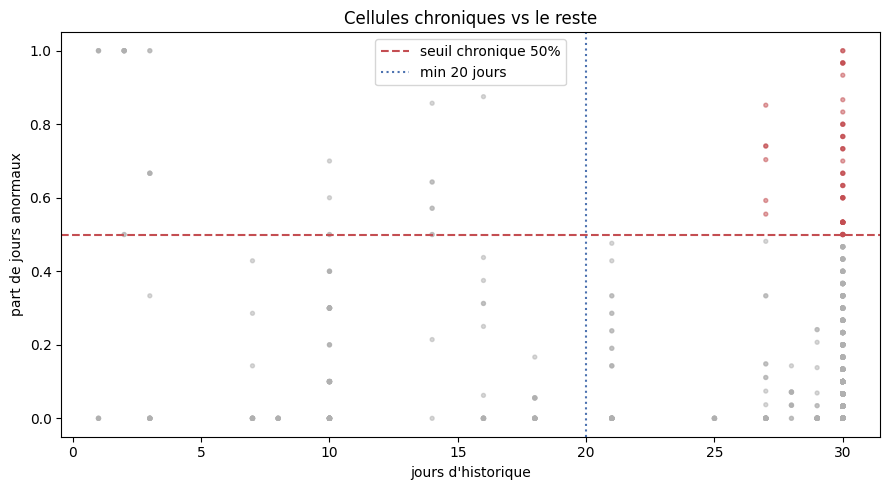

In [32]:
# Visualisation : chaque point = une cellule (jours d'historique vs part de jours
# anormaux). En rouge les chroniques (au-dessus du seuil), en gris le reste.
plt.figure(figsize=(9, 5))
col = np.where(cell_stat["is_chronique"], "#C44E52", "#B0B0B0")
plt.scatter(cell_stat["n_days"], cell_stat["taux_anormal"], s=8, c=col, alpha=0.5)
plt.axhline(SEUIL_CHRONIQUE, color="#C44E52", ls="--", label=f"seuil chronique {SEUIL_CHRONIQUE:.0%}")
plt.axvline(MIN_DAYS, color="#4C72B0", ls=":", label=f"min {MIN_DAYS} jours")
plt.xlabel("jours d'historique"); plt.ylabel("part de jours anormaux")
plt.title("Cellules chroniques vs le reste"); plt.legend()
plt.tight_layout(); plt.show()

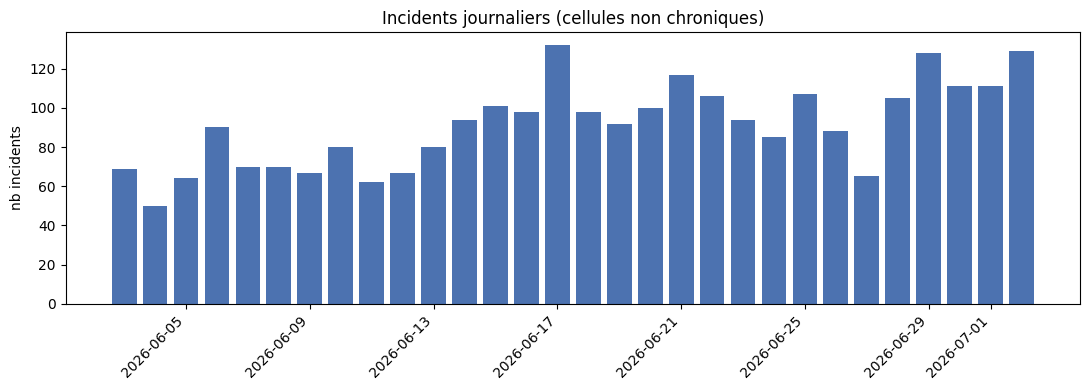

In [33]:
# Nombre d'incidents par jour (cellules non chroniques). Montre quand les incidents se
# concentrent -> a rapprocher plus tard des pics de reclamations.
per_day = incidents.groupby("Date").size()
plt.figure(figsize=(11, 4))
plt.bar(per_day.index, per_day.values, color="#4C72B0")
plt.title("Incidents journaliers (cellules non chroniques)")
plt.ylabel("nb incidents"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

In [34]:
# --- Explicabilite : SHAP (TreeSHAP sur Isolation Forest) ---
# Attribution rigoureuse du score d'anomalie a chaque KPI (valeurs de Shapley, Lundberg &
# Lee 2017 ; TreeSHAP Lundberg 2020). Calculee sur les cellules-jours flaguees uniquement
# (~top 3%) -> rapide. C'est la methode qui remplace toute lecture directe du z.
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

kpi_names = [c[2:] for c in z_cols]
flag_idx = np.where(flag_if)[0]
lbl = D.index[flag_idx]
explainer = shap.TreeExplainer(iforest)
shap_flag = explainer.shap_values(X_scaled[flag_idx])

# Sens de l'attribution fixe sur les donnees : on aligne le signe pour que
# "positif = pousse vers l'anomalie" (score IForest eleve).
sign = int(np.sign(np.corrcoef(shap_flag.sum(axis=1), score_if[flag_idx])[0, 1]))
shap_anom = shap_flag * sign
shap_df = pd.DataFrame(shap_anom, index=lbl, columns=kpi_names)
print("Signe verifie (corr somme SHAP / score anomalie) :", sign)

# KPI en cause = KPI dont la contribution SHAP vers l'anomalie est la plus forte.
# Un incident a souvent PLUSIEURS KPI defaillants. On liste TOUS les KPI a contribution
# SHAP positive (= qui poussent vers l'anomalie), classes du plus fort au plus faible, en
# plus du principal. Utile car la plainte client peut venir d'un KPI defaillant qui n'est
# pas LE pire.
def kpis_positifs(row):
    r = row[row > 0].sort_values(ascending=False)
    return "; ".join(r.index)

incidents["kpi_principal"] = shap_df.idxmax(axis=1).reindex(incidents.index)
incidents["kpis_en_cause"] = shap_df.apply(kpis_positifs, axis=1).reindex(incidents.index)

# Chroniques : moyenne des contributions SHAP sur les jours flagues -> dominant + liste.
cell_of = D.loc[lbl, "EUtranCell Id"].values
shap_cell = shap_df.groupby(cell_of).mean()
chroniques["kpi_dominant"] = shap_cell.idxmax(axis=1).reindex(chroniques.index)
chroniques["kpis_en_cause"] = shap_cell.apply(kpis_positifs, axis=1).reindex(chroniques.index)
print("Nb moyen de KPI en cause par incident :",
      round(incidents["kpis_en_cause"].str.count(";").add(1).mean(), 1))

Signe verifie (corr somme SHAP / score anomalie) : -1


Nb moyen de KPI en cause par incident : 4.7


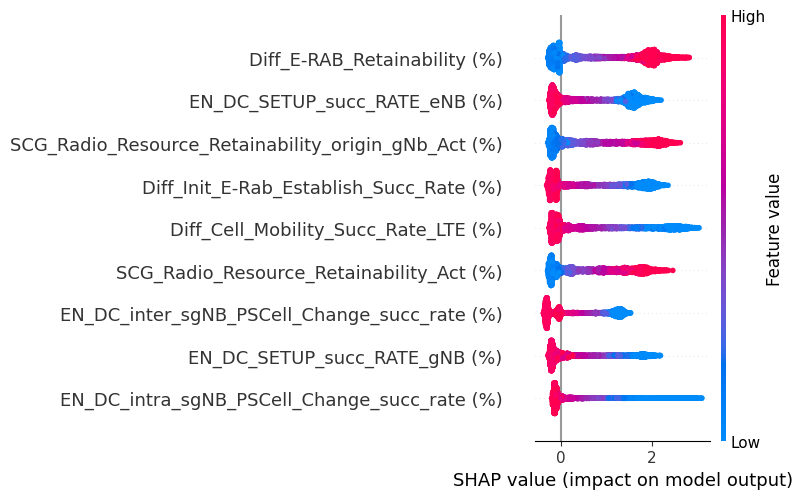

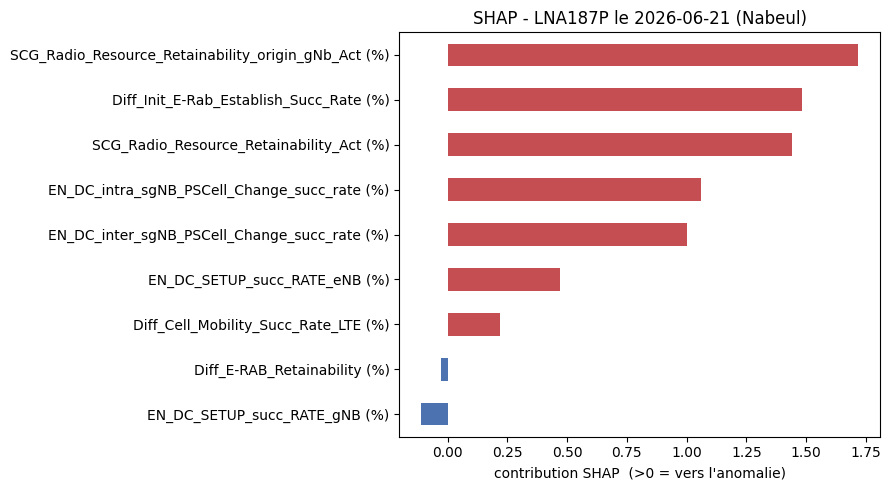

Incident le plus fort : LNA187P | 2026-06-21 | KPI en cause : SCG_Radio_Resource_Retainability_origin_gNb_Act (%); Diff_Init_E-Rab_Establish_Succ_Rate (%); SCG_Radio_Resource_Retainability_Act (%); EN_DC_intra_sgNB_PSCell_Change_succ_rate (%); EN_DC_inter_sgNB_PSCell_Change_succ_rate (%); EN_DC_SETUP_succ_RATE_eNB (%); Diff_Cell_Mobility_Succ_Rate_LTE (%)


In [35]:
# SHAP global sur les cellules-jours flaguees : quels KPI portent le plus les anomalies
# (valeur positive = pousse vers l'anomalie).
shap.summary_plot(shap_anom, X_scaled[flag_idx], feature_names=kpi_names, show=False)
plt.tight_layout(); plt.show()

# SHAP individuel : incident le plus fort, contribution de chaque KPI.
top_lbl = incidents.sort_values("score_if", ascending=False).index[0]
contrib = shap_df.loc[top_lbl].sort_values()
info = D.loc[top_lbl]
plt.figure(figsize=(9, 5))
contrib.plot(kind="barh", color=["#C44E52" if v > 0 else "#4C72B0" for v in contrib])
plt.title(f"SHAP - {info['EUtranCell Id']} le {info['Date'].date()} ({info['Region']})")
plt.xlabel("contribution SHAP  (>0 = vers l'anomalie)")
plt.tight_layout(); plt.show()
print("Incident le plus fort :", info["EUtranCell Id"], "|", info["Date"].date(),
      "| KPI en cause :", incidents.loc[top_lbl, "kpis_en_cause"])

In [36]:
# --- Exports pour la suite (KPI reels + Node, sans z-scores) ---
import os
OUT = "resultats_anomalies"
os.makedirs(OUT, exist_ok=True)
node_of = df.groupby("EUtranCell Id")["Node"].first()
kpi_mean = df.groupby("EUtranCell Id")[kpi_cols].mean().round(2)

# Incidents : valeurs KPI reelles de la cellule-jour + KPI en cause (SHAP).
inc = df.loc[incidents.index, ["Node", "EUtranCell Id", "Region", "Date"] + kpi_cols].copy()
inc = inc.join(incidents[["score_if", "kpi_principal", "kpis_en_cause"]])
inc.sort_values(["Date", "score_if"], ascending=[True, False]).to_csv(f"{OUT}/anomalies_journalieres.csv", index=False)

# Chroniques : moyenne des KPI reels de la cellule + KPI dominant (SHAP) + Node.
chr_out = chroniques[["region", "n_days", "n_flag", "taux_anormal", "kpi_dominant", "kpis_en_cause"]].copy()
chr_out.insert(0, "Node", node_of.reindex(chr_out.index))
chr_out = chr_out.join(kpi_mean)
chr_out.sort_values("taux_anormal", ascending=False).to_csv(f"{OUT}/cellules_chroniques.csv")

# Faible historique : Node + comptes (jamais etiquetees chroniques).
low = cell_low.rename("n_days").to_frame()
low.insert(0, "Node", node_of.reindex(low.index))
low["n_jours_flagues"] = D.groupby("EUtranCell Id")["flag"].sum().reindex(low.index)
low.to_csv(f"{OUT}/cellules_historique_insuffisant.csv")

print("resultats_anomalies/anomalies_journalieres.csv     :", len(inc))
print("resultats_anomalies/cellules_chroniques.csv        :", len(chr_out))
print("resultats_anomalies/cellules_historique_insuffisant:", len(low))

resultats_anomalies/anomalies_journalieres.csv     : 2730
resultats_anomalies/cellules_chroniques.csv        : 53
resultats_anomalies/cellules_historique_insuffisant: 179
